In [57]:
#09-12-2025

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [59]:
file_path=r'C:\Users\vijay\Documents\NareshIT\data_files\Visadataset.csv'

In [60]:
visa_df=pd.read_csv(file_path)

In [61]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [62]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [63]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [64]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- there are total 25480 applicants

- out of 25480 applicant 17018 got visas

- out of 25480 8462 applicants denied visas

- from asia 16861 applicant applied for visas

- we want to know how many applicants from asia got certifed

- we want to know how many applcants from asia denied visa

In [65]:
visa_df['continent']
con1=visa_df['continent']=='Asia' 
con2=visa_df['case_status']=='Certified'
print(con2)
con=con1 & con2
#visa_df[con]
print(len(visa_df[con]))
    

0        False
1         True
2        False
3        False
4         True
         ...  
25475     True
25476     True
25477     True
25478     True
25479     True
Name: case_status, Length: 25480, dtype: bool
11012


In [66]:
labels=visa_df['continent'].unique()

In [67]:
certified_count=[]
denied_count=[]
for i in labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    cer_con = con1 & con2
    den_cond= con1 & con3
    certified_count.append(len(visa_df[cer_con]))
    denied_count.append(len(visa_df[den_cond]))
    cols=sorted(visa_df['case_status'].unique())


In [68]:
pd.DataFrame(zip(certified_count,denied_count),columns=cols,index=labels)                        

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


- case_status-continent-education of employee

In [69]:
#from asia there are 16k applicants for visa
#out of that 11012 certified
#5649 denied
# we want to know education of those applicant

In [70]:
#crosstab(<index>,<column>)
col1=visa_df['continent']
col2=visa_df['case_status']
r2=pd.crosstab(col1,col2)
r2

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

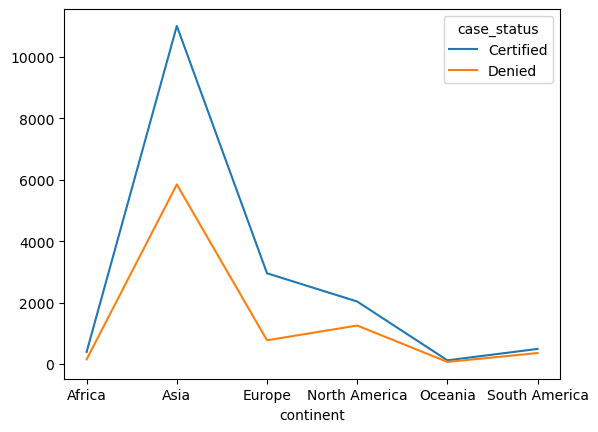

In [71]:
r2.plot()

<Axes: xlabel='continent'>

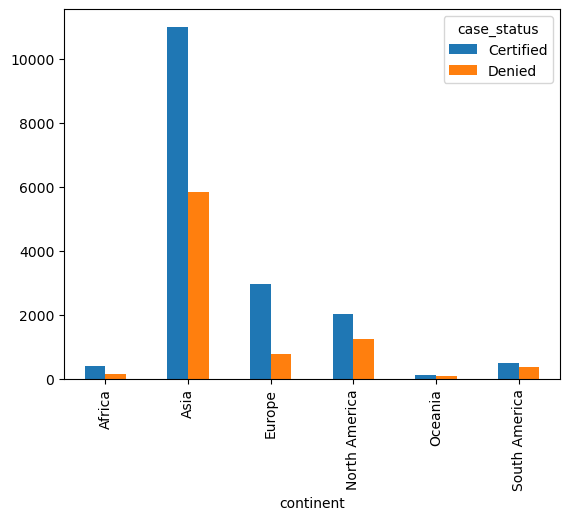

In [72]:
r2.plot(kind='bar')

In [73]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2=pd.crosstab(col1,cols)
r2

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

**group by**

In [74]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [75]:
visa_df['prevailing_wage']
# wages are numerical values
# 25480 applicants are available
# different applicants having the different wages

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [76]:
list(visa_df.groupby('education_of_employee'))

[("Bachelor's",
           case_id      continent education_of_employee has_job_experience  \
  2         EZYV03           Asia            Bachelor's                  N   
  3         EZYV04           Asia            Bachelor's                  N   
  6         EZYV07           Asia            Bachelor's                  N   
  7         EZYV08  North America            Bachelor's                  Y   
  8         EZYV09           Asia            Bachelor's                  N   
  ...          ...            ...                   ...                ...   
  25466  EZYV25467         Europe            Bachelor's                  Y   
  25468  EZYV25469           Asia            Bachelor's                  N   
  25473  EZYV25474           Asia            Bachelor's                  Y   
  25475  EZYV25476           Asia            Bachelor's                  Y   
  25479  EZYV25480           Asia            Bachelor's                  Y   
  
        requires_job_training  no_of_employee

In [77]:
visa_df.groupby('education_of_employee').count()

,case_id,continent,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
education_of_employee,,,,,,,,,,,
Bachelor's,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234
Doctorate,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192
High School,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420
Master's,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634


In [78]:
visa_df.groupby('education_of_employee').size()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [79]:
visa_df.groupby('education_of_employee')['prevailing_wage'].count()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
Name: prevailing_wage, dtype: int64

In [80]:
visa_df['prevailing_wage'].mean()

np.float64(74455.81459209183)

In [81]:
visa_df[visa_df['education_of_employee']=="Bachelor's"]['prevailing_wage'].mean()

np.float64(73405.44373547)

In [82]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [88]:
#dir(visa_df)

'abs', 'add', 'add_prefix', 'add_suffix', 'agg', 'aggregate', 'align', 'all', 'any', 'apply', 'applymap', 'asfreq', 'asof', 'assign',
 'astype', 'at', 'at_time', 'attrs', 'axes', 'backfill', 'between_time', 'bfill', 'bool', 'boxplot', 'case_id', 'case_status', 'clip',
 'columns', 'combine', 'combine_first', 'compare', 'continent', 'convert_dtypes', 'copy', 'corr', 'corrwith', 'count', 'cov', 'cummax',
 'cummin'
 'cumprod',
 'cumsum',
 'describe',
 'diff',
 'div',
 'divide',
 'dot',
 'drop',
 'drop_duplicates',
 'droplevel',
 'dropna',
 'dtypes',
 'duplicated',
 'education_of_employee',
 'empty',
 'eq',
 'equals',
 'eval',
 'ewm',
 'expanding',
 'explode',
 'ffill',
 'fillna',
 'filter',
 'first',
 'first_valid_index',
 'flags',
 'floordiv',
 'from_dict',
 'from_records',
 'full_time_position',
 'ge',
 'get',
 'groupby',
 'gt',
 'has_job_experience',
 'head',
 'hist',
 'iat',
 'idxmax',
 'idxmin',
 'iloc',
 'index',
 'infer_objects',
 'info',
 'insert',
 'interpolate',
 'isetitem',
 'isin',
 'isna',
 'isnull',
 'items',
 'iterrows',
 'itertuples',
 'join',
 'keys',
 'kurt',
 'kurtosis',
 'last',
 'last_valid_index',
 'le',
 'loc',
 'lt',
 'map',
 'mask',
 'max',
 'mean',
 'median',
 'melt',
 'memory_usage',
 'merge',
 'min',
 'mod',
 'mode',
 'mul',
 'multiply',
 'ndim',
 'ne',
 'nlargest',
 'no_of_employees',
 'notna',
 'notnull',
 'nsmallest',
 'nunique',
 'pad',
 'pct_change',
 'pipe',
 'pivot',
 'pivot_table',
 'plot',
 'pop',
 'pow',
 'prevailing_wage',
 'prod',
 'product',
 'quantile',
 'query',
 'radd',
 'rank',
 'rdiv',
 'region_of_employment',
 'reindex',
 'reindex_like',
 'rename',
 'rename_axis',
 'reorder_levels',
 'replace',
 'requires_job_training',
 'resample',
 'reset_index',
 'rfloordiv',
 'rmod',
 'rmul',
 'rolling',
 'round',
 'rpow',
 'rsub',
 'rtruediv',
 'sample',
 'select_dtypes',
 'sem',
 'set_axis',
 'set_flags',
 'set_index',
 'shape',
 'shift',
 'size',
 'skew',
 'sort_index',
 'sort_values',
 'squeeze',
 'stack',
 'std',
 'style',
 'sub',
 'subtract',
 'sum',
 'swapaxes',
 'swaplevel',
 'tail',
 'take',
 'to_clipboard',
 'to_csv',
 'to_dict',
 'to_excel',
 'to_feather',
 'to_gbq',
 'to_hdf',
 'to_html',
 'to_json',
 'to_latex',
 'to_markdown',
 'to_numpy',
 'to_orc',
 'to_parquet',
 'to_period',
 'to_pickle',
 'to_records',
 'to_sql',
 'to_stata',
 'to_string',
 'to_timestamp',
 'to_xarray',
 'to_xml',
 'transform',
 'transpose',
 'truediv',
 'truncate',
 'tz_convert',
 'tz_localize',
 'unit_of_wage',
 'unstack',
 'update',
 'value_counts',
 'values',
 'var',
 'where',
 'xs',
 'yr_of_estab'

In [84]:
con=visa_df['case_status']=='Certified'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [85]:
con=visa_df['case_status']=='Denied'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa            154
Asia             5849
Europe            775
North America    1255
Oceania            70
South America     359
dtype: int64

In [86]:
# i want to know min wage of the Asia ppl
visa_df['prevailing_wage'].min()  # 25480
con=visa_df['continent']=='Asia'
new_df=visa_df[con]
new_df['prevailing_wage'].min()

3.3188

In [87]:
visa_df.groupby('continent')['prevailing_wage'].min()

continent
Africa           32.9286
Asia              3.3188
Europe            9.1753
North America     2.1367
Oceania          24.4888
South America     3.0031
Name: prevailing_wage, dtype: float64

In [89]:
#10-12-2025

In [ ]:
- we have seen continet and case status

- we have seen three column continet and case status and education of employees

- we have seen same analysis using group by

- only categorical column analysis completed

- only nunerical column analysis completed

- Bi variate and mutivariate analysis completed

- now we have to perform two numerical analysis

    - This will give relation between two column which are numerical in nature

    - we can perform corelation matrix to get the relation between two variable

    - we will draw sactter plot





**scatter plot**

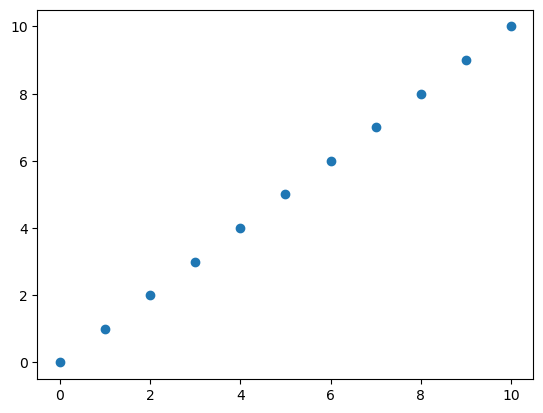

In [90]:
x=range(0,11)
y=range(0,11)
plt.scatter(x,y)

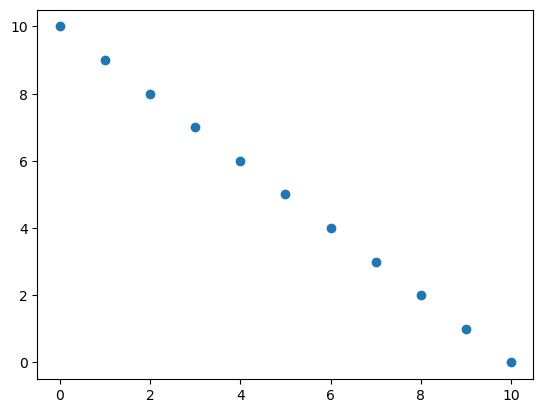

In [91]:
x=range(0,11)
y=range(10,-1,-1)
plt.scatter(x,y)

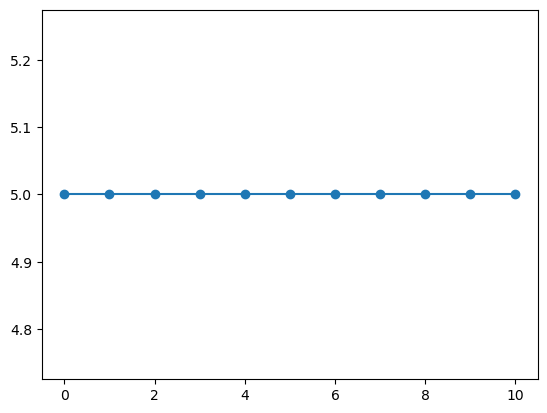

In [95]:
x=range(0,11)
y=[5 for i in range(0,11)]
plt.scatter(x,y)
plt.plot(x,y)

In [96]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [97]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [98]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


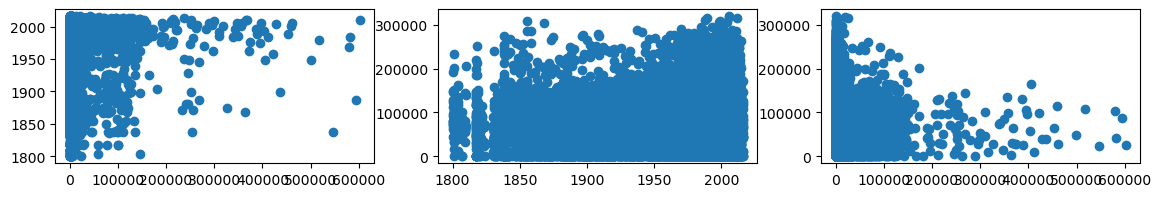

In [115]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(14,2))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

In [116]:
file_path=r'C:\Users\vijay\Documents\NareshIT\data_files\winequality_red.csv'

In [118]:
wine_df=pd.read_csv(file_path)

In [134]:
wine_df_corr=wine_df.corr()
wine_df_corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


**heat map**

- any matrix values can be visualize by using heat map

- heat map will provide different colour for differet values

- heat map also provide colour bar with its value

- for example **blue colour** value range from 0.8 to 1 then blue bar displays against this 

- so by looking at colour bar we can predict values pertaining to that colour

- heat map available in seabor


<Axes: >

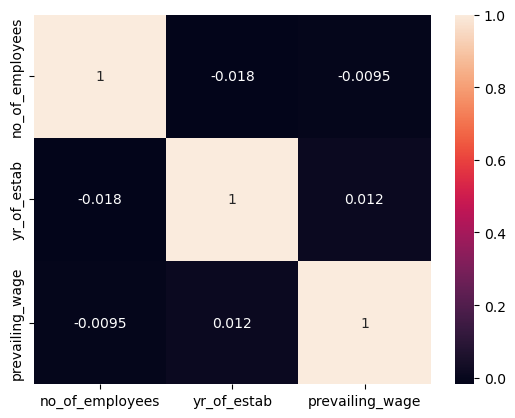

In [141]:
visa_df_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_df_corr,annot=True)

<Axes: >

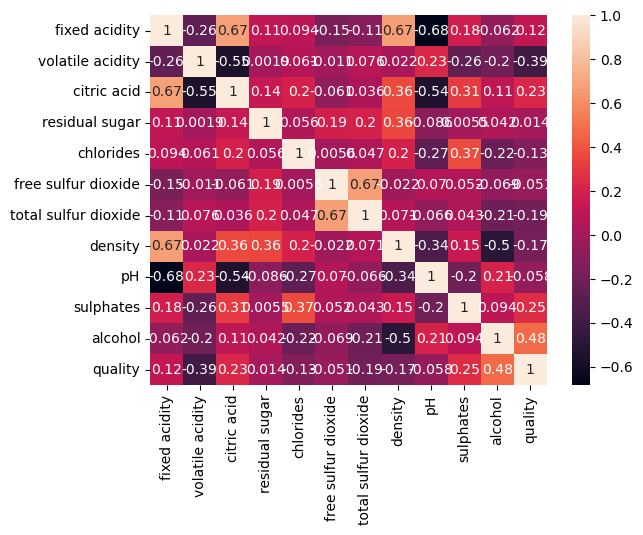

In [140]:
wine_df_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_df_corr,annot=True)

In [153]:
 col1=wine_df['fixed acidity']
 col2=wine_df['volatile acidity']
 col3=wine_df['citric acid']
 col4=wine_df['residual sugar']
 col5=wine_df['chlorides']
 col6=wine_df['free sulfur dioxide']
 col7=wine_df['total sulfur dioxide']
 col8=wine_df['density']
 col9=wine_df['pH']
 col10=wine_df['sulphates']
 col11=wine_df['alcohol']
 col12=wine_df['quality']

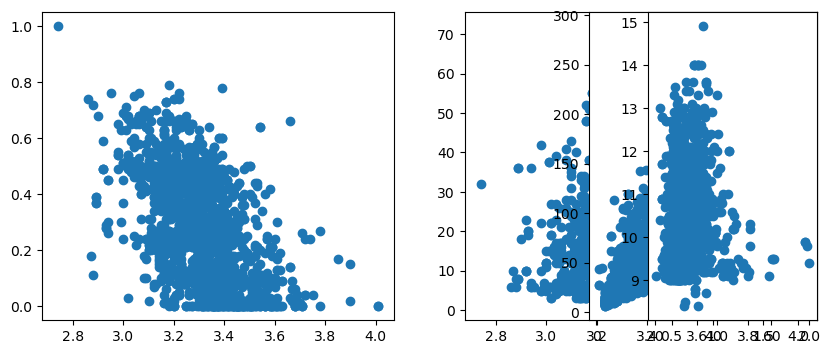

In [168]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1).scatter(col9,col3)
plt.subplot(1,2,2).scatter(col9,col6)
plt.subplot(1,3,3).scatter(col6,col7)
plt.subplot(1,4,4).scatter(col10,col11)